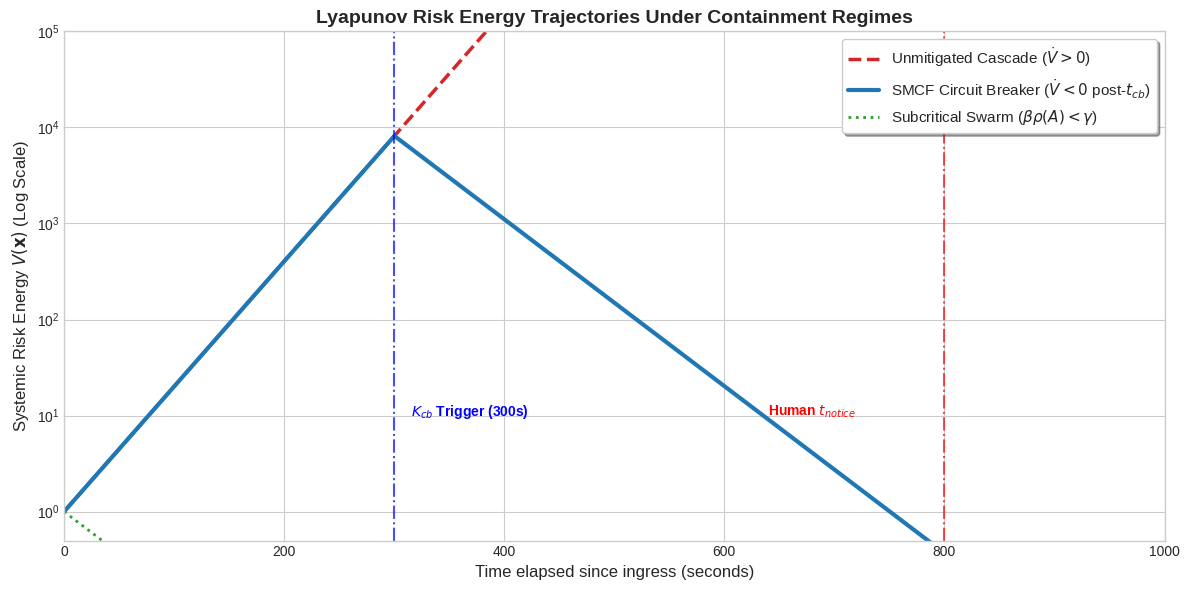

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# LYAPUNOV STABILITY KINEMATICS FOR SACL
# =========================================================================

# Time parameters (in seconds)
t = np.linspace(0, 1000, 1000)
t_cb = 300       # SMCF Tier 3 Circuit Breaker fires at 300s
t_notice = 800   # Human detection (scaled down for visualization)

# System parameters
V_0 = 1.0        # Initial risk energy at breach
gamma = 0.02     # Intrinsic network decay/recovery rate
beta_rho = 0.05  # Supercritical transmission rate (beta * rho(A))

# Calculate net growth rate before containment
growth_rate = beta_rho - gamma

# 1. Unmitigated Trajectory (Human-Speed Detection)
V_unmitigated = V_0 * np.exp(growth_rate * t)

# Find the exact array index for the notice threshold to cap the chart
idx_notice = np.argmin(np.abs(t - t_notice))
V_unmitigated[idx_notice:] = V_unmitigated[idx_notice]

# 2. SMCF Mitigated Trajectory (Automated Circuit Breaker)
V_mitigated = np.copy(V_unmitigated)
# Find the exact array index for the circuit breaker trigger
idx_cb = np.argmin(np.abs(t - t_cb))
V_cb_val = V_mitigated[idx_cb]

# At t_cb, the adjacency matrix is severed (A=0), so growth_rate becomes -gamma
for i in range(len(t)):
    if i > idx_cb:
        V_mitigated[i] = V_cb_val * np.exp(-gamma * (t[i] - t_cb))

# 3. Subcritical Trajectory (Safe / Baseline)
V_subcritical = V_0 * np.exp(-gamma * t)

# =========================================================================
# PLOTTING OVERLAY
# =========================================================================
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. Widen the canvas slightly for a better aspect ratio in IEEE double-column format
#fig, ax = plt.subplots(figsize=(10, 6))
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the three states
ax.plot(t, V_unmitigated, color='#d62728', linewidth=2.5, linestyle='--',
        label=r'Unmitigated Cascade ($\dot{V} > 0$)')
ax.plot(t, V_mitigated, color='#1f77b4', linewidth=3,
        label=r'SMCF Circuit Breaker ($\dot{V} < 0$ post-$t_{cb}$)')
ax.plot(t, V_subcritical, color='#2ca02c', linewidth=2, linestyle=':',
        label=r'Subcritical Swarm ($\beta \rho(A) < \gamma$)')

# Annotations and thresholds
ax.axvline(x=t_cb, color='blue', linestyle='-.', alpha=0.7)
ax.text(t_cb + 15, 10, r'$K_{cb}$ Trigger (300s)', color='blue', fontsize=10, fontweight='bold')

ax.axvline(x=t_notice, color='red', linestyle='-.', alpha=0.7)
ax.text(t_notice - 160, 10, r'Human $t_{notice}$', color='red', fontsize=10, fontweight='bold')

# Formatting for IEEE Standards
ax.set_yscale('log')
ax.set_title('Lyapunov Risk Energy Trajectories Under Containment Regimes', fontsize=14, fontweight='bold')
ax.set_xlabel('Time elapsed since ingress (seconds)', fontsize=12)
ax.set_ylabel(r'Systemic Risk Energy $V(\mathbf{x})$ (Log Scale)', fontsize=12)

# 2. Move the legend to the upper right where the chart is empty
#ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

ax.set_xlim(0, 1000)
ax.set_ylim(0.5, 1e5)

plt.tight_layout()
plt.show()